In [79]:
!pip install optuna 

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 2.8 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.1 MB 3.0 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.4 MB/s  0:00:00

   ------ --------------------------------- 1/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------------- ------------- 4/6 [alembic]
   --------------------------------- ------ 5/6 [optuna]
   -------------------------

In [80]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from scipy.interpolate import griddata
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppresses the massive wall of text

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')


In [5]:

# 1. Load Data
df = pd.read_csv("./data/df_features.csv")
df['trading_date'] = pd.to_datetime(df['trading_date'])
df = df.sort_values('trading_date').reset_index(drop=True)
df = df[(df['trading_date'] > '2019-04-30') & (df['trading_date'] < '2026-03-26')].reset_index(drop=True).copy()

In [6]:
split_idx = int(len(df) * 0.90)

train_df = df.loc[:split_idx].copy()
test_df = df.loc[split_idx+1:].copy()

{'a': 2, 'b': 2}

In [ ]:
train_df[train_df['trading_date'].isin(['2024-01', '2024-01-24'])][['trading_date', 'msft_return', 'prepped_sentiment']]

,trading_date,msft_return,prepped_sentiment


In [137]:


from sklearn.metrics import mean_absolute_error


class VolatilityRiskPipeline:
    """
    End-to-End Quantitative Pipeline for 21-Day Forward Volatility Prediction.
    Includes Categorical EDA, Walk-Forward Validation, LightGBM Modeling, and SHAP Interpretability.
    """
    
    def __init__(self, df: pd.DataFrame, target_col: str = 'target_vol_21d', date_col: str = 'trading_date',test_size=0.15):
        
        # Ensure chronological order (Critical for Time-Series)
        self.df = df.copy()
        self.df[date_col] = pd.to_datetime(self.df[date_col])
        self.df = self.df.sort_values(date_col).reset_index(drop=True)
        
        self.target = target_col
        self.date_col = date_col
        self.model = None
        self.explainer = None
        
        split_idx = int(len(self.df) * (1 - test_size))
        self.train_val_df = self.df.iloc[:split_idx].reset_index(drop=True)
        
        # 15% of data locked in "The Vault" for final evaluation
        self.test_df = self.df.iloc[split_idx:].reset_index(drop=True)
        
        print(f"🔒 Data Split Complete:")
        print(f"   Train/Val Set: {len(self.train_val_df)} days (Ends: {self.train_val_df[date_col].max().date()})")
        print(f"   Holdout Test Set: {len(self.test_df)} days (Starts: {self.test_df[date_col].min().date()})")
        
        # ---------------------------------------------------------
        # THE FEATURE TAXONOMY
        # ---------------------------------------------------------
        self.feature_groups = {
                        "Price_Dynamics": ['vol_rolling_21d', 'msft_return', 'dist_from_ma200', 'vol_garman_klass', \
                            'amihud_ratio', 'msft_vs_market', 'msft_vs_tech'],
                        "Macro_Regime": ['vix_level', 'vix_5d_trend', 'yield_10y_level', 'yield_10y_delta_5d','qqq_vol_21d','vol_surge'],
                        "NLP_Sentiment": [ "prepped_dispersion", "prepped_neutral",
    "qa_sentiment", "qa_dispersion", "qa_neutral","sec_sentiment", "sec_neutral", "sec_dispersion"],
                        "Fundamental_Accounting": ['roa', 'debt_to_asset', 'fcf_margin', 'net_income_qoq', 'cash_coverage'],
                        "Temporal": ['days_since_earnings', 'days_since_filing']
}        
        # Flatten for model training
        self.all_features = [feat for group in self.feature_groups.values() for feat in group]

    def set_active_features(self, custom_feature_list: list):
        """
        Surgically prunes the feature space to prevent dimensionality noise.
        Overrides the default 'all_features' list initialized in the class.
        """
        old_count = len(self.all_features)
        new_count = len(custom_feature_list)
        
        # Validation check: Ensure the core price features still exist so the Baseline model doesn't crash
        core_price = self.feature_groups["Price_Dynamics"]
        missing_core = [f for f in core_price if f not in custom_feature_list]
        if missing_core:
            print(f"⚠️ Warning: You pruned core baseline features: {missing_core}. The Baseline model may fail.")
            
        self.all_features = custom_feature_list
        print(f"✂️ Feature Space Pruned: Reduced from {old_count} down to {new_count} high-conviction features.")
    
    # ==========================================
    # PHASE 2: MODEL TRAINING & VALIDATION
    # ==========================================
    
    # ==========================================
    # PHASE 2: MODEL PROGRESSION & VALIDATION
    # ==========================================
    
    
    # ==========================================
    # PHASE 2.5: BAYESIAN OPTIMIZATION (OPTUNA)
    # ==========================================
    def optimize_lgbm_hyperparameters(self, n_trials: int = 30, n_splits: int = 5):
        """
        Uses Bayesian Optimization to find the optimal regularization parameters 
        for the LightGBM model without exhaustive Grid Search.
        """
        print(f"\n🚀 Launching Optuna Bayesian Optimization ({n_trials} Trials)...")
        print("Target: Maximizing Shrinkage & Regularization on Walk-Forward CV")
        
        # We only tune on the Train/Val set!
        X = self.train_val_df[self.all_features]
        y = self.train_val_df[self.target]
        tscv = TimeSeriesSplit(n_splits=n_splits)

        def objective(trial):
            # 1. Define the Search Space (Strictly constrained for small datasets)
            param_grid = {
                'objective': 'regression',
                'metric': 'rmse',
                'learning_rate': 0.02, # Hardcoded slow learning
                'verbosity': -1,
                'seed': 42,
                
                # The "Shrinkage" Parameters Optuna will tweak:
                'max_depth': trial.suggest_int('max_depth', 3, 6),
                'num_leaves': trial.suggest_int('num_leaves', 7, 31),
                'min_child_samples': trial.suggest_int('min_child_samples', 20, 60),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True) # L2
            }

            cv_scores = []
            
            # 2. Evaluate this specific parameter combination using Walk-Forward CV
            for train_idx, val_idx in tscv.split(X):
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

                model = lgb.LGBMRegressor(**param_grid, n_estimators=2000)
                callbacks = [lgb.early_stopping(stopping_rounds=25, verbose=False)]

                model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=callbacks
                )

                preds = model.predict(X_val)
                rmse = np.sqrt(mean_squared_error(y_val, preds))
                cv_scores.append(rmse)

            # Optuna's goal is to minimize this average out-of-sample RMSE
            return np.mean(cv_scores)

        # 3. Run the Optimization
        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=n_trials)

        print("\n🏆 OPTIMIZATION COMPLETE 🏆")
        print(f"Best Out-of-Sample CV RMSE: {study.best_value:.4f}")
        print("Best Parameters Found:")
        for key, value in study.best_params.items():
            if isinstance(value, float):
                print(f"   {key}: {value:.4f}")
            else:
                print(f"   {key}: {value}")
                
        return study.best_params
        
    def compare_model_progression(self, n_splits: int = 5,tuned_params:dict=None):
        """
        Executes Walk-Forward Validation across 3 distinct tiers to prove Alpha generation:
        1. Naive Baseline (Pure Autoregressive Math)
        2. Price-Only LightGBM (Standard Quant Model)
        3. Full Alpha LightGBM (Custom NLP + Macro)
        """
        
        
        print(f"🚀 Executing Walk-Forward Validation ({n_splits} Folds)...")
        
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        # Trackers for our 3 models
        naive_scores = []
        price_scores = []
        alpha_scores = []
        
        # Define the subset for the Price-Only baseline
        price_features = self.feature_groups["Price_Dynamics"]
        
        X = self.train_val_df[self.all_features]
        y = self.train_val_df[self.target]
        
        # Institutional constraints to prevent overfitting
    
        params = {
            'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.01,"num_threads":6,"n_estimators": 2000,"max_depth": 5,\
            "min_samples_leaf": 40, "colsample_bytree": 0.6, 'reg_alpha': 1, 'reg_lambda': 1, \
            'verbosity': -1, 'seed': 42
        }
        callbacks = [lgb.early_stopping(stopping_rounds=15, verbose=True)]

        if tuned_params:
            params.update(tuned_params)
        else:
            
            for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
                
                # --------------------------------------------------
                # TIER 1: Naive Baseline (Math Only)
                # Assumption: Future volatility equals historical rolling volatility
                # --------------------------------------------------
                naive_preds = X_val['vol_rolling_21d']
                naive_rmse = np.sqrt(mean_squared_error(y_val, naive_preds))
                naive_scores.append(naive_rmse)
                
                
                # --------------------------------------------------
                # TIER 2: Price-Only LightGBM
                # --------------------------------------------------
                model_price = lgb.LGBMRegressor(**params)
                model_price.fit(
                    X_train[price_features], y_train,
                    eval_set=[(X_val[price_features], y_val)],
                    callbacks=callbacks
                )
                price_preds = model_price.predict(X_val[price_features])
                price_rmse = np.sqrt(mean_squared_error(y_val, price_preds))
                price_scores.append(price_rmse)
                
                # --------------------------------------------------
                # TIER 3: The Alpha Model (Full Feature Space)
                # --------------------------------------------------
                model_alpha = lgb.LGBMRegressor(**params)
                model_alpha.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=callbacks
                )
                alpha_preds = model_alpha.predict(X_val)
                alpha_rmse = np.sqrt(mean_squared_error(y_val, alpha_preds))
                alpha_scores.append(alpha_rmse)
                
                print(f"Fold {fold+1} | Naive: {naive_rmse:.4f} | Price-LGBM: {price_rmse:.4f} | Alpha-LGBM: {alpha_rmse:.4f}")
            
        # Calculate final averages
        avg_naive = np.mean(naive_scores)
        avg_price = np.mean(price_scores)
        avg_alpha = np.mean(alpha_scores)
        
        print("\n" + "="*50)
        print("🏆 FINAL OUT-OF-SAMPLE RMSE RESULTS")
        print("="*50)
        print(f"1. Naive Baseline (Autoregressive):  {avg_naive:.4f}")
        print(f"2. Price-Only LightGBM:              {avg_price:.4f}")
        print(f"3. Full Alpha LightGBM (NLP+Macro):  {avg_alpha:.4f}")
        
        alpha_value = ((avg_price - avg_alpha) / avg_price) * 100
        print(f"\n💡 Alpha Value Add: Unstructured features improved the ML baseline by {alpha_value:.2f}%.")
        
        # Save the final alpha model to the class instance for SHAP later
        final_model = lgb.LGBMRegressor(**params, callbacks=callbacks)
        final_model.fit(X, y)
        self.model = final_model
        self.plot_model_progression(avg_naive, avg_price, avg_alpha)

    def plot_model_progression(self, avg_naive, avg_price, avg_alpha):
        """Generates the 'Mic Drop' bar chart for the presentation slide."""
        print("\n--- SANITY CHECK: TARGET VARIANCE MISMATCH ---")
        print(f"Train Set Target Mean: {self.train_val_df[self.target].mean():.4f} | Std Dev (Chaos): {self.train_val_df[self.target].std():.4f}")
        print(f"Test Set Target Mean:  {self.test_df[self.target].mean():.4f} | Std Dev (Chaos): {self.test_df[self.target].std():.4f}")
        plt.figure(figsize=(10, 6))
        
        models = ['1. Naive Baseline\n(Rolling Vol)', '2. Price-Only LGBM\n(Technical Quant)', '3. The Alpha Model\n(NLP + Macro + Price)']
        scores = [avg_naive, avg_price, avg_alpha]
        colors = ['#d3d3d3', '#8faadc', '#2e5597'] # Grey, Light Blue, Deep Corporate Blue
        
        bars = plt.bar(models, scores, color=colors, width=0.6)
        
        plt.ylabel('Out-of-Sample RMSE (Lower is Better)')
        plt.title('Model Progression: Isolating the Alpha Value Add', pad=20, fontsize=14, fontweight='bold')
        
        # Add data labels on top of bars
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
            
        # Draw an arrow showing the Alpha Drop
        plt.annotate(
            '', xy=(2, avg_alpha), xytext=(1, avg_price),
            arrowprops=dict(arrowstyle="->", color="red", lw=2, ls='--')
        )
        plt.text(1.5, (avg_price+avg_alpha)/2 + 0.002, 'Value Add\nof NLP', color='red', ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()
    
    
    
    # ==========================================
    # PHASE 3: INTERPRETABILITY (SHAP)
    # ==========================================
    def generate_shap_explanations(self):
        """Extracts native feature importance and directional SHAP values."""
        if self.model is None:
            raise ValueError("Model must be trained before generating SHAP values.")
            
        print("🚀 Extracting Model Interpretability...")
        X = self.train_val_df[self.all_features]
        
        # 1. Native Feature Importance
        lgb.plot_importance(self.model, max_num_features=15, importance_type='gain', 
                            figsize=(10, 6), title="LightGBM Global Feature Importance (Information Gain)")
        plt.tight_layout()
        plt.show()

        # 2. SHAP Summary Plot (Directionality)
        self.explainer = shap.TreeExplainer(self.model)
        shap_values = self.explainer.shap_values(X)
        
        plt.figure(figsize=(10, 6))
        plt.title("SHAP Summary: Feature Directionality")
        shap.summary_plot(shap_values, X, show=False)
        plt.tight_layout()
        plt.show()

    def generate_local_shap_force(self, index: int):
        """Generates a local explanation for a specific trading day."""
        if self.explainer is None:
            raise ValueError("Run generate_shap_explanations() first to initialize SHAP.")
            
        X = self.test_df[self.all_features]
        date = self.test_df.loc[index, self.date_col].strftime('%Y-%m-%d')
        actual_vol = self.test_df.loc[index, self.target]
        
        # 1. Extract the row as a 2D DataFrame for the model and SHAP math
        row_2d = X.iloc[[index]]
        
        # 2. Extract the row as a 1D Series for the plot labels
        row_1d = X.iloc[index]
        
        predicted_vol = self.model.predict(row_2d)[0]
        
        print(f"📅 Trading Date: {date}")
        print(f"Actual Volatility: {actual_vol:.4f} | Predicted Volatility: {predicted_vol:.4f}")
        
        # Note: shap.initjs() is required if running in a Jupyter Notebook
        shap.initjs()
        
        # Pass the 2D DataFrame to calculate SHAP values
        shap_values = self.explainer.shap_values(row_2d)
        
        # force_plot expects: (Base Value, 1D Array of SHAP values, 1D Series of features)
        return shap.force_plot(
            self.explainer.expected_value, 
            shap_values[0], 
            row_1d
        )
    
    def evaluate_on_test_set(self):
        """
        Unlocks the holdout Test Set to calculate the final, true out-of-sample 
        institutional metrics (RMSE, Hit Rate, Tail-RMSE) for the deployment decision.
        """
        if self.model is None:
            raise ValueError("You must run compare_model_progression() to train the model first.")
            
        print("\n" + "="*50)
        print("🚨 UNLOCKING THE VAULT: FINAL TEST SET EVALUATION 🚨")
        print("="*50)

        # X and y for the unseen Test Set
        X_test = self.test_df[self.all_features]
        y_test = self.test_df[self.target]
        
        # Predict on the unseen data
        preds = self.model.predict(X_test)
        
        # --------------------------------------------------
        # 1. Global RMSE & Mean Error
        # --------------------------------------------------
        test_rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_mae = mean_absolute_error(y_test, preds)
        mean_error = np.mean(preds - y_test)
        
        print(f"1. Final Test RMSE:           {test_rmse:.4f}")
        print(f"2. Systematic Bias:           {mean_error:.4f} "
              f"({'Under-predicting' if mean_error < 0 else 'Over-predicting'} risk)")
        print(f"3. Final Test MAE:            {test_mae:.4f}")
        
        plt.figure(figsize=(12, 6))
        
        # Plot the lines
        plt.plot(self.test_df['trading_date'], self.test_df[self.target], label='Actual 21-Day Volatility', color='#d3d3d3', linewidth=2)
        plt.plot(self.test_df['trading_date'], preds, label='Predicted Risk (Alpha Model)', color='#2e5597', linewidth=2)
        
        plt.title('Out-of-Sample Tracking: Predicted vs. Actual Risk', fontweight='bold', pad=15)
        plt.ylabel('Annualized Volatility')
        plt.xlabel('Trading Date')
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(8, 5))
        
        er = preds - y_test
        # Plot the histogram of errors
        plt.hist(er, bins=30, color='#2e5597', alpha=0.7, edgecolor='white')
        
        # Draw the "Danger Line" (Zero error)
        plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Zero Error (Perfect Match)')
        
        # Draw the Model's actual bias
        plt.axvline(mean_error, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean Bias (+{mean_error:.4f})')
        
        plt.title('Out-of-Sample Error Distribution (Residuals)', fontweight='bold', pad=15)
        plt.xlabel('Prediction Error (Predicted - Actual)')
        plt.ylabel('Frequency (Days)')
        
        # Add a text box explaining the safety buffer
        plt.text(0.05, 0.95, 'Positive Error = Conservative (Safe)\nNegative Error = Under-hedged (Danger)', 
                 transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.legend()
        plt.tight_layout()
        plt.show()

        # --------------------------------------------------
        # 2. Tail-RMSE (Crisis Performance on Unseen Data)
        # --------------------------------------------------
        threshold_90 = np.percentile(y_test, 90)
        tail_idx = y_test >= threshold_90
        
        tail_rmse = np.sqrt(mean_squared_error(y_test[tail_idx], preds[tail_idx]))
        print(f"3. Tail-RMSE (Top 10% events): {tail_rmse:.4f}")

        # --------------------------------------------------
        # 3. Directional Hit Rate
        # --------------------------------------------------
        current_vol = self.test_df['vol_rolling_21d']
        actual_direction = np.sign(y_test - current_vol)
        predicted_direction = np.sign(preds - current_vol)
        
        hit_rate = np.mean(actual_direction == predicted_direction) * 100
        print(f"4. Directional Hit Rate:      {hit_rate:.2f}%")
        
        print("5. Generating Out-of-Sample Calibration Plot (Quintiles)...")
        
        calib_df = pd.DataFrame({'Actual': y_test, 'Predicted': preds})
        
        # Downgraded to 5 buckets (Quintiles) to ensure statistical significance on a small test set
        calib_df['Quintile'] = pd.qcut(calib_df['Predicted'].rank(method='first'), q=5, labels=False) + 1
        
        quintile_stats = calib_df.groupby('Quintile').mean()

        plt.figure(figsize=(8, 5))
        x = np.arange(5)
        width = 0.35

        plt.bar(x - width/2, quintile_stats['Predicted'], width, label='Avg Predicted Volatility', color='#2e5597')
        plt.bar(x + width/2, quintile_stats['Actual'], width, label='Avg Actual Volatility', color='#d3d3d3')

        plt.xlabel('Predicted Risk Quintile (1 = Lowest, 5 = Highest Risk)', fontweight='bold')
        plt.ylabel('Annualized Volatility', fontweight='bold')
        plt.title('TRUE OUT-OF-SAMPLE CALIBRATION\n(Holdout Test Set - Quintile Resolution)', pad=15)
        plt.xticks(x, ['Q1 (Safe)', 'Q2', 'Q3', 'Q4', 'Q5 (Danger)'])
        plt.legend()
        plt.tight_layout()
        plt.show()
# ==========================================
# EXECUTION SCRIPT
# ==========================================


In [138]:
# if __name__ == "__main__":
# Assume 'train_df' is your fully engineered dataframe
pipeline = VolatilityRiskPipeline(df=train_df)

pruned_features = [
        # The Core Baseline (Do not remove these, the Tier 2 model needs them)
        'vol_rolling_21d', 
        'msft_return', 
        'dist_from_ma200', 
        'vol_garman_klass', 
        'amihud_ratio','msft_vs_market', 'msft_vs_tech',
        
        # The Proven Alpha (Your Top 3 non-price features from SHAP)
        'qa_dispersion',
        'vix_level',
        'fcf_margin',
        'yield_10y_level',
        'prepped_neutral',
        'days_since_earnings',
        'cash_coverage','qqq_vol_21d',
        'qa_sentiment',
        'prepped_sentiment'
    ]
    

    # 3. Execute the Pruning
pipeline.set_active_features(pruned_features)
# 2. Model Development & Validation



🔒 Data Split Complete:
   Train/Val Set: 1105 days (Ends: 2023-09-19)
   Holdout Test Set: 196 days (Starts: 2023-09-20)
✂️ Feature Space Pruned: Reduced from 28 down to 17 high-conviction features.


🚀 Executing Walk-Forward Validation (5 Folds)...
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's rmse: 0.347328
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.351127
Fold 1 | Naive: 0.3280 | Price-LGBM: 0.3473 | Alpha-LGBM: 0.3511
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[83]	valid_0's rmse: 0.0939999
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 0.112405
Fold 2 | Naive: 0.0789 | Price-LGBM: 0.0940 | Alpha-LGBM: 0.1124
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[66]	valid_0's rmse: 0.072702
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[39]	valid_0's rmse: 0.0716315
Fold 3 | Naive: 0.0573 | Price-LGBM: 0.0727 | Alph

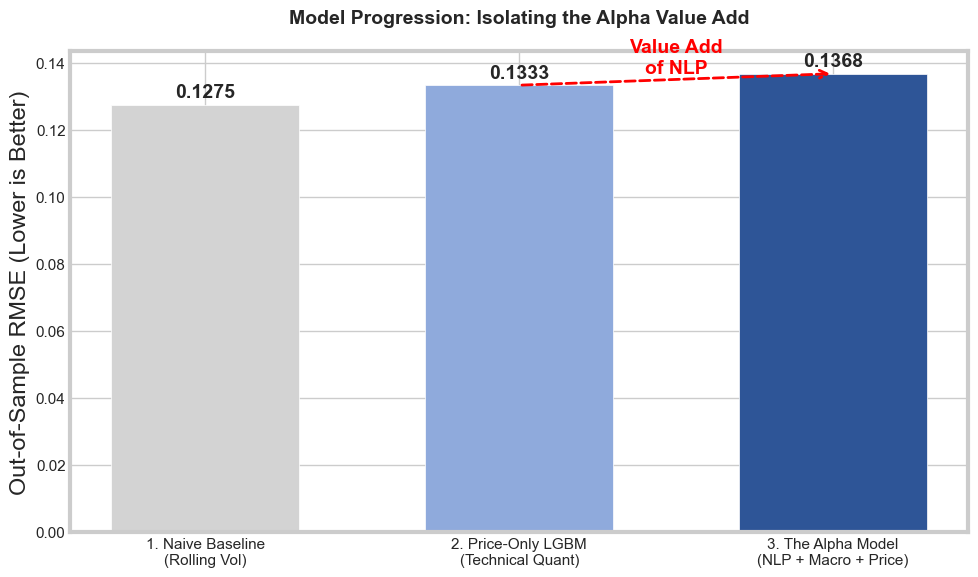

🚀 Extracting Model Interpretability...


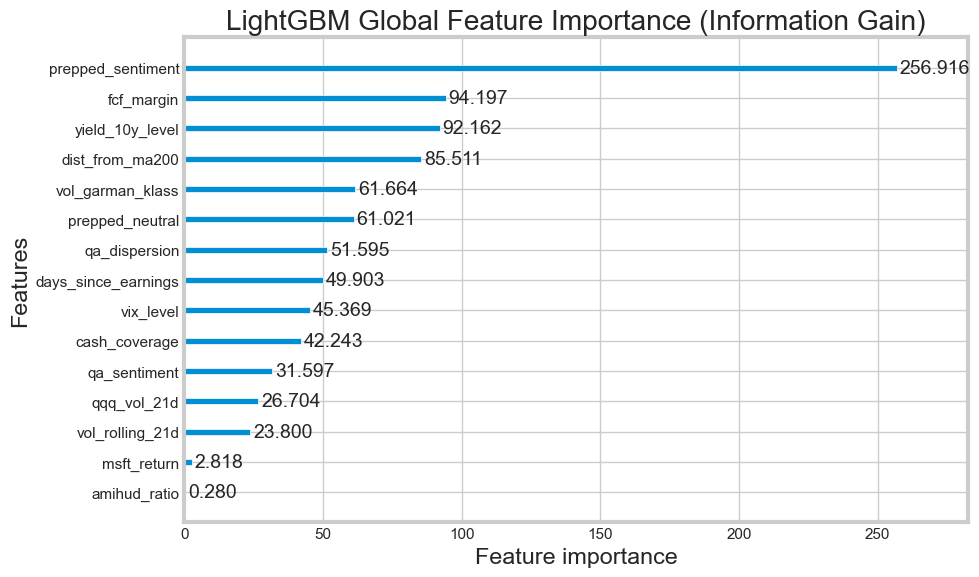

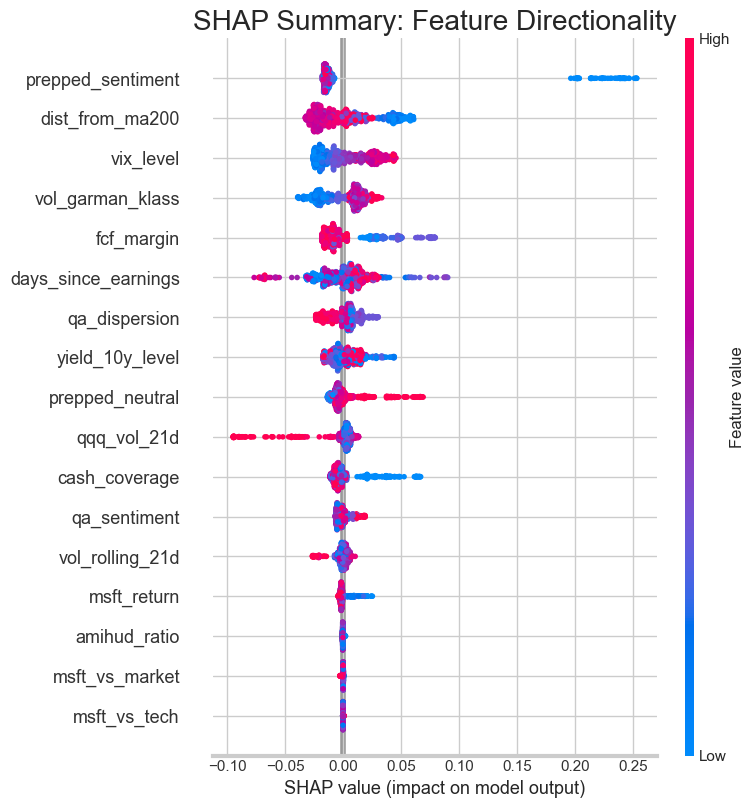

📅 Trading Date: 2024-02-13
Actual Volatility: 0.2094 | Predicted Volatility: 0.2585



🚨 UNLOCKING THE VAULT: FINAL TEST SET EVALUATION 🚨
1. Final Test RMSE:           0.0512
2. Systematic Bias:           0.0402 (Over-predicting risk)
3. Final Test MAE:            0.0435


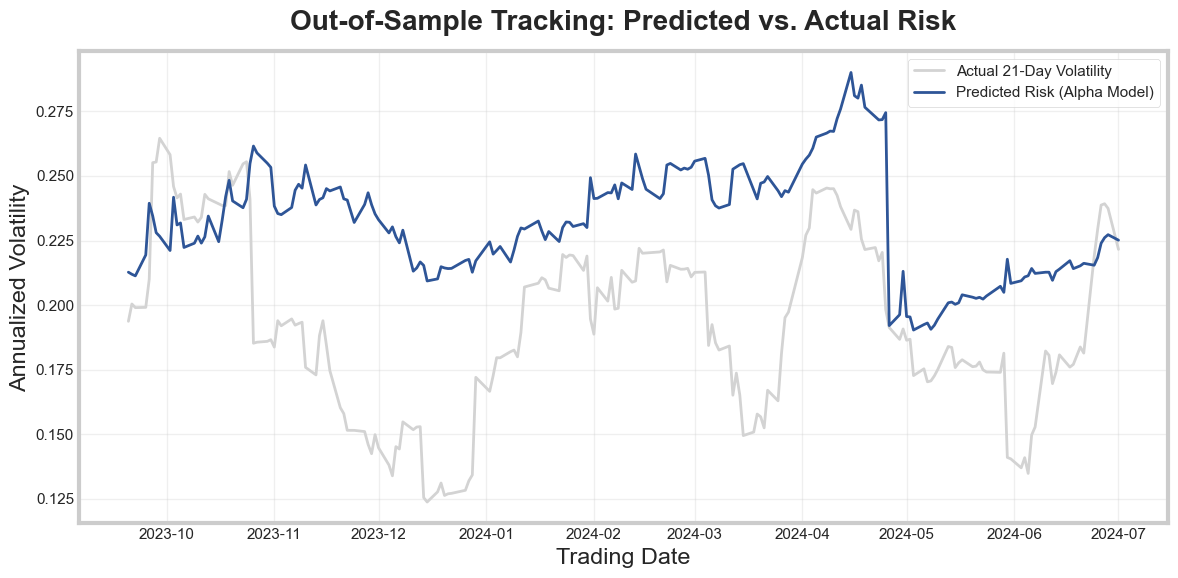

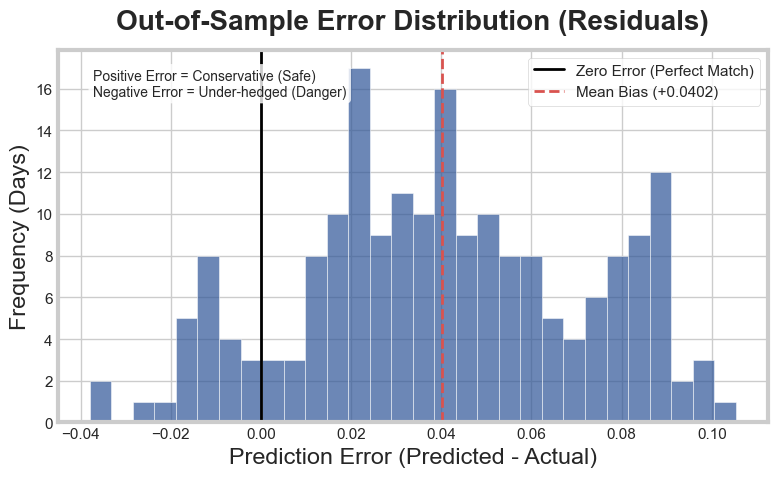

3. Tail-RMSE (Top 10% events): 0.0204
4. Directional Hit Rate:      61.73%
5. Generating Out-of-Sample Calibration Plot (Quintiles)...


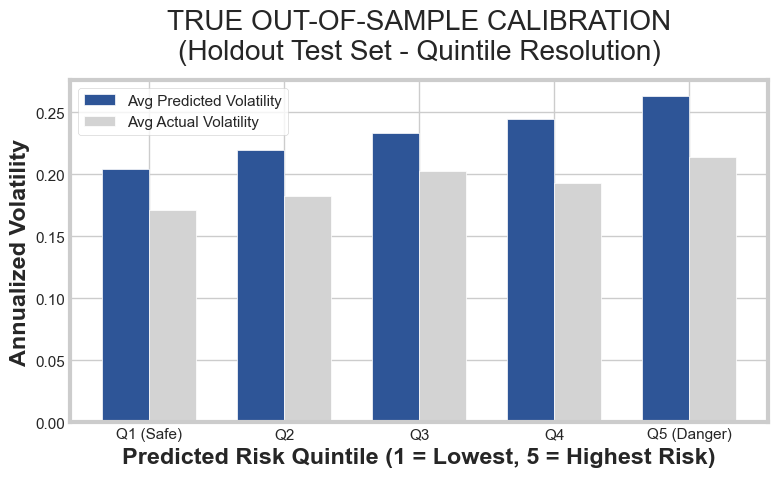

In [139]:
pipeline.compare_model_progression(n_splits=5)

# 3. Model Interpretability
pipeline.generate_shap_explanations()

# 4. Local Day Analysis (Pick a known day of extreme volatility)
pipeline.generate_local_shap_force(index=100)


pipeline.evaluate_on_test_set()


In [140]:

best_params = pipeline.optimize_lgbm_hyperparameters(n_trials=30)


🚀 Launching Optuna Bayesian Optimization (30 Trials)...
Target: Maximizing Shrinkage & Regularization on Walk-Forward CV

🏆 OPTIMIZATION COMPLETE 🏆
Best Out-of-Sample CV RMSE: 0.1346
Best Parameters Found:
   max_depth: 6
   num_leaves: 10
   min_child_samples: 49
   colsample_bytree: 0.5881
   reg_lambda: 0.2600


🚀 Executing Walk-Forward Validation (5 Folds)...

🏆 FINAL OUT-OF-SAMPLE RMSE RESULTS
1. Naive Baseline (Autoregressive):  nan
2. Price-Only LightGBM:              nan
3. Full Alpha LightGBM (NLP+Macro):  nan

💡 Alpha Value Add: Unstructured features improved the ML baseline by nan%.

--- SANITY CHECK: TARGET VARIANCE MISMATCH ---
Train Set Target Mean: 0.2839 | Std Dev (Chaos): 0.1455
Test Set Target Mean:  0.1925 | Std Dev (Chaos): 0.0343


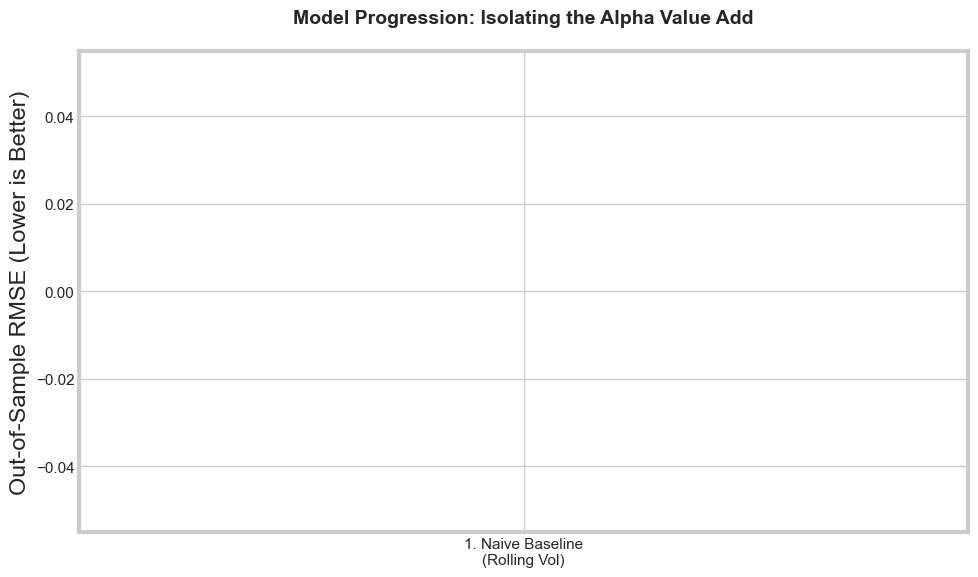

In [141]:
pipeline.compare_model_progression(n_splits=5,tuned_params=best_params)

🚀 Extracting Model Interpretability...


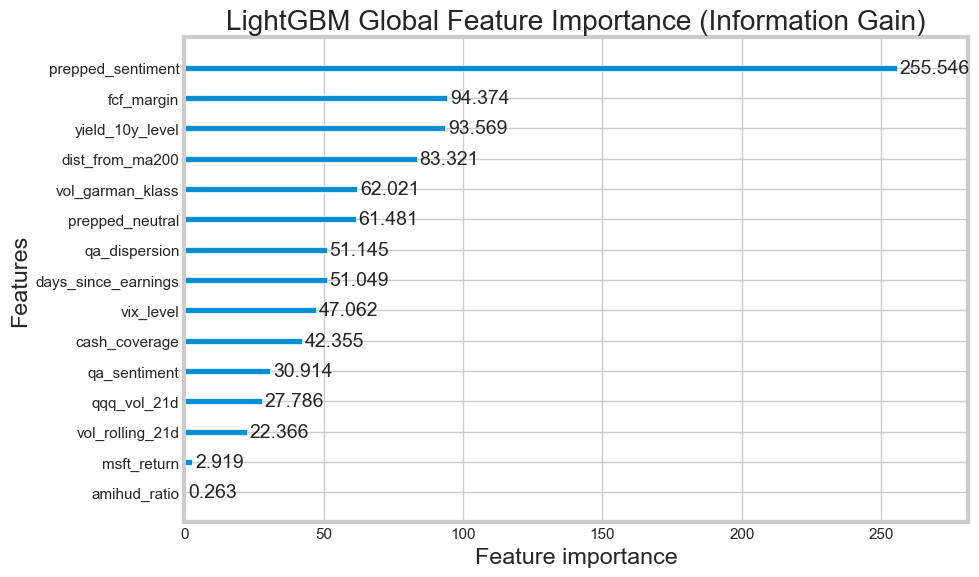

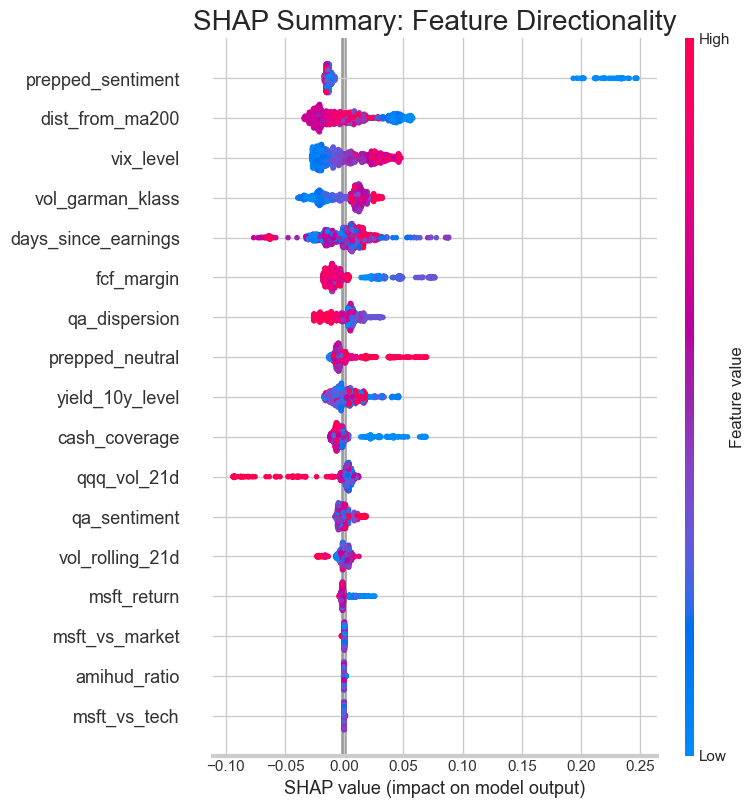

📅 Trading Date: 2024-02-13
Actual Volatility: 0.2094 | Predicted Volatility: 0.2640



🚨 UNLOCKING THE VAULT: FINAL TEST SET EVALUATION 🚨
1. Final Test RMSE:           0.0506
2. Systematic Bias:           0.0402 (Over-predicting risk)
3. Final Test MAE:            0.0430


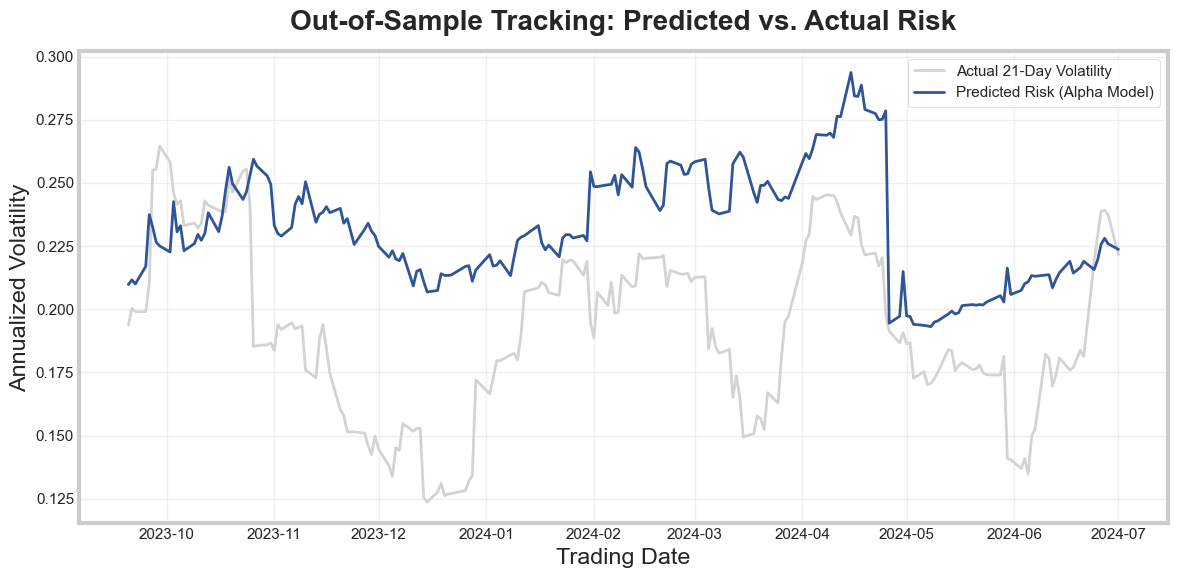

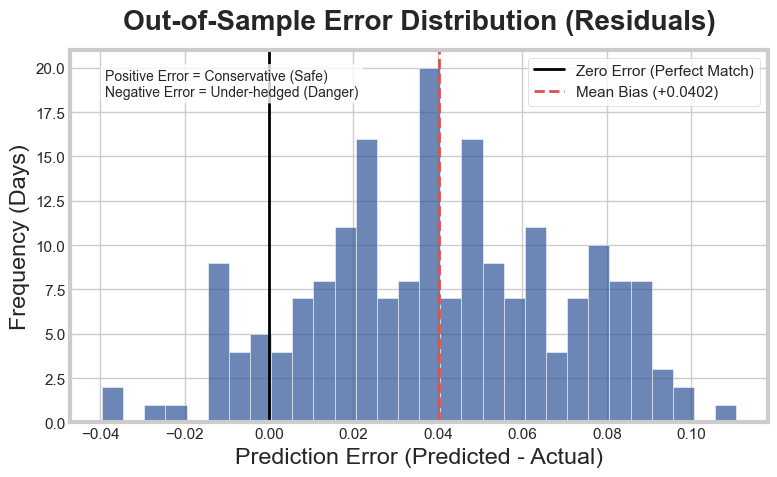

3. Tail-RMSE (Top 10% events): 0.0210
4. Directional Hit Rate:      63.78%
5. Generating Out-of-Sample Calibration Plot (Quintiles)...


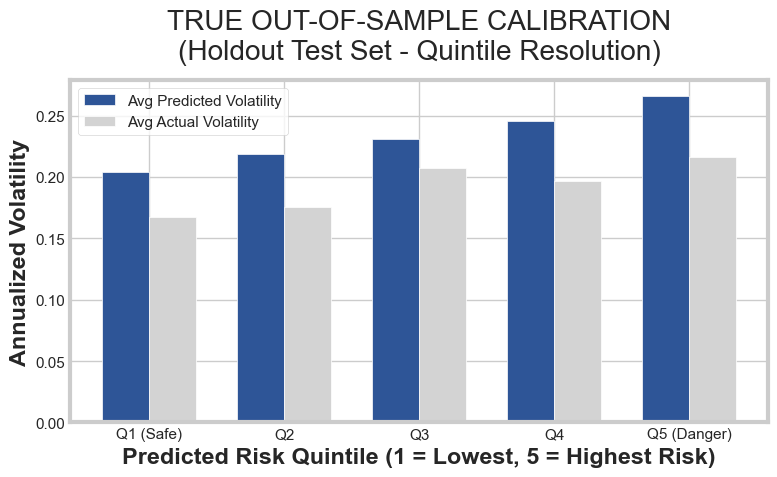

In [142]:
# 3. Model Interpretability
pipeline.generate_shap_explanations()

# 4. Local Day Analysis (Pick a known day of extreme volatility)
pipeline.generate_local_shap_force(index=100)


pipeline.evaluate_on_test_set()


In [136]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

OUTDIR = "output/model_roadmap"
os.makedirs(OUTDIR, exist_ok=True)

# =========================
# Load data
# =========================

TARGET = "target_vol_21d"

baseline_features = [
    "vix_level", "vol_rolling_21d", "qqq_vol_21d", "vol_garman_klass",
    "qqq_return", "spy_return", "msft_return", "yield_10y_level",
    "yield_10y_delta_5d", "amihud_ratio", "dist_from_ma200"
]

extended_features = baseline_features + [
    "roa", "cash_coverage", "debt_to_asset", "fcf_margin", "net_income_qoq",
    "sec_sentiment", "sec_neutral", "sec_dispersion",
     "prepped_dispersion", "prepped_neutral","prepped_sentiment",
    "qa_sentiment", "qa_dispersion", "qa_neutral",
    "days_since_earnings", "days_since_filing",
    "msft_vs_tech", "msft_vs_market", "vol_surge"
]

baseline_features = [c for c in baseline_features if c in df.columns]
extended_features = [c for c in extended_features if c in df.columns]

model_df = df.dropna(subset=[TARGET]).copy()

# =========================
# Chronological split
# =========================
n = len(model_df)
train_end = int(n * 0.75)
valid_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
valid_df = model_df.iloc[train_end:valid_end].copy()
test_df  = model_df.iloc[valid_end:].copy()

# =========================
# Metrics
# =========================
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Spearman": spearmanr(y_true, y_pred, nan_policy="omit").correlation
    }

# =========================
# Pipelines
# =========================
def make_ridge_pipeline(features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    preprocessor = ColumnTransformer(
        transformers=[("num", numeric_transformer, features)],
        remainder="drop"
    )
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ])
    return model

def make_tree_pipeline(features, model_type="rf"):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])
    preprocessor = ColumnTransformer(
        transformers=[("num", numeric_transformer, features)],
        remainder="drop"
    )

    if model_type == "rf":
        reg = RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    else:
        reg = GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.01,
            max_depth=4,
            max_features=0.6,
            min_samples_leaf=30,
            
            random_state=42,
            n_iter_no_change=3
        )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", reg)
    ])
    return model

# =========================
# Train/eval helper
# =========================
def fit_and_eval(train_df, valid_df, test_df, features, estimator_name, model):
    X_train, y_train = train_df[features], train_df[TARGET]
    X_valid, y_valid = valid_df[features], valid_df[TARGET]
    X_test, y_test = test_df[features], test_df[TARGET]

    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    pred_test = model.predict(X_test)

    valid_metrics = regression_metrics(y_valid, pred_valid)
    test_metrics = regression_metrics(y_test, pred_test)

    out_valid = valid_df[["trading_date", TARGET]].copy()
    out_valid["prediction"] = pred_valid
    out_valid["dataset"] = "validation"

    out_test = test_df[["trading_date", TARGET]].copy()
    out_test["prediction"] = pred_test
    out_test["dataset"] = "test"

    preds = pd.concat([out_valid, out_test], axis=0)
    preds.to_csv(os.path.join(OUTDIR, f"preds_{estimator_name}.csv"), index=False)

    row = {
        "model": estimator_name,
        "n_features": len(features),
        **{f"valid_{k}": v for k, v in valid_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()}
    }
    return row, preds, model

# =========================
# Run model suite
# =========================
results = []
artifacts = {}

model_specs = [
    ("gbr_baseline", baseline_features, make_tree_pipeline(baseline_features, "gbr")),
    ("gbr_extended", extended_features, make_tree_pipeline(extended_features, "gbr")),
]

for name, feats, model in model_specs:
    row, preds, fitted = fit_and_eval(train_df, valid_df, test_df, feats, name, model)
    results.append(row)
    artifacts[name] = {"preds": preds, "model": fitted, "features": feats}

results_df = pd.DataFrame(results).sort_values("test_RMSE")
results_df.to_csv(os.path.join(OUTDIR, "model_comparison.csv"), index=False)
print(results_df)

# =========================
# Plot model comparison
# =========================
plt.figure(figsize=(10, 6))
plot_df = results_df.sort_values("test_RMSE")
sns.barplot(data=plot_df, x="test_RMSE", y="model", color="#4C78A8")
plt.title("Model Comparison by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "model_comparison_rmse.png"), dpi=180, bbox_inches="tight")
plt.close()

# =========================
# Choose best model
# =========================
best_model_name = results_df.iloc[0]["model"]
best = artifacts[best_model_name]
best_preds = best["preds"]
best_preds.to_csv(os.path.join(OUTDIR, "best_model_predictions.csv"), index=False)
feature_names = best["features"]
best_test = best_preds[best_preds["dataset"] == "test"].copy()

plt.figure(figsize=(14, 5))
plt.plot(best_test["trading_date"], best_test[TARGET], label="Actual", color="#4C78A8")
plt.plot(best_test["trading_date"], best_test["prediction"], label="Predicted", color="#E45756")
plt.title(f"Best Model Test Predictions: {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_test_timeseries.png"), dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(6, 6))
sns.scatterplot(data=best_test, x=TARGET, y="prediction", alpha=0.5)
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_actual_vs_pred.png"), dpi=180, bbox_inches="tight")
plt.close()

# =========================
# Optional SHAP
# =========================
shap_done = False
try:
    import shap

    if best_model_name.startswith("rf") or best_model_name.startswith("gbr"):
        fitted_model = best["model"]
        features = best["features"]

        X_train = train_df[features].copy()
        X_test = test_df[features].copy()

        preprocessor = fitted_model.named_steps["preprocessor"]
        model = fitted_model.named_steps["model"]

        X_train_proc = preprocessor.transform(X_train)
        X_test_proc = preprocessor.transform(X_test)
        X_train_proc_df = pd.DataFrame(X_train_proc, columns=features, index=X_train.index)
        X_test_proc_df = pd.DataFrame(X_test_proc, columns=features, index=X_test.index)

        explainer = shap.Explainer(model, X_train_proc_df)
        shap_values = explainer(X_test_proc_df[:200])

        plt.figure()
        shap.plots.beeswarm(shap_values, max_display=15, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "shap_beeswarm.png"), dpi=180, bbox_inches="tight")
        plt.close()

        plt.figure()
        shap.summary_plot(shap_values, show=False)
        plt.savefig(os.path.join(OUTDIR, "shap_summary.png"), dpi=180, bbox_inches="tight")
        plt.tight_layout()
        plt.close()
               
        plt.figure()
        shap.plots.bar(shap_values, max_display=15, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "shap_bar.png"), dpi=180, bbox_inches="tight")
        plt.close()

        shap_done = True

except Exception as e:
    print("SHAP skipped:", e)

# =========================
# Notes
# =========================
notes = []
notes.append("Model development workflow completed.")
notes.append(f"Best model by test RMSE: {best_model_name}")
notes.append("Files generated:")
notes.append("- model_comparison.csv")
notes.append("- model_comparison_rmse.png")
notes.append("- best_model_predictions.csv")
notes.append("- best_model_test_timeseries.png")
notes.append("- best_model_actual_vs_pred.png")
notes.append("- preds_<model>.csv for each candidate model")
if shap_done:
    notes.append("- shap_beeswarm.png")
    notes.append("- shap_bar.png")
else:
    notes.append("- SHAP plots were skipped or unavailable")

with open(os.path.join(OUTDIR, "README.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(notes))

print("All modeling artifacts saved to", OUTDIR)

          model  n_features  valid_MAE  valid_RMSE  valid_R2  valid_Spearman  \
1  gbr_extended          30   0.049328    0.061039 -0.398604        0.126921   
0  gbr_baseline          11   0.054169    0.065976 -0.633978       -0.319470   

   test_MAE  test_RMSE   test_R2  test_Spearman  
1  0.081124   0.098730  0.245292        0.62416  
0  0.082154   0.104316  0.157467        0.45846  
All modeling artifacts saved to output/model_roadmap
